# Optimized Classification Model with Feature Importance Analysis

## Predicting E-Commerce Purchase Likelihood Using Machine Learning

### Objective
The objective of this project is to build and optimize a machine learning classification model that predicts whether an e-commerce customer is likely to make a purchase based on browsing behavior, customer profile, and engagement data.

### Project Workflow
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis
4. Data Preprocessing
5. Baseline Model Training
6. Model Evaluation
7. Hyperparameter Optimization
8. Feature Importance Analysis
9. Threshold Analysis
10. Business Recommendations
11. Save the Best Model

In [34]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Save Model
import joblib

# Display Settings
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [35]:
df = pd.read_csv("../data/ecommerce_customer_data.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,CustomerID,Age,Gender,Location,DeviceType,TrafficSource,PagesViewed,TimeOnSite,ProductsViewed,CartItems,PreviousPurchases,AverageOrderValue,DiscountUsed,EmailClicked,AdClicked,ReviewScoreViewed,DaysSinceLastVisit,SessionCount,Purchase
0,100001,56,Female,West,Desktop,Email,16,163,7,5,9,420.96,1,1,0,1.3,35,18,0
1,100002,69,Male,West,Mobile,Search,25,1090,8,1,23,264.70,1,1,0,4.1,17,4,1
2,100003,46,Female,South,Mobile,Advertisement,19,122,7,3,4,166.27,1,1,0,1.4,43,5,0
3,100004,32,Male,North,Desktop,Search,2,104,8,4,20,272.19,0,1,0,4.1,20,8,0
4,100005,60,Female,South,Desktop,Social Media,15,785,4,7,18,181.48,1,1,0,2.1,3,4,1


In [36]:
print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print("\n")

print("=" * 60)
print("Dataset Information")
print("=" * 60)
df.info()

print("\n")

print("=" * 60)
print("Missing Values")
print("=" * 60)
print(df.isnull().sum())

print("\n")

print("=" * 60)
print("Duplicate Records")
print("=" * 60)
print(df.duplicated().sum())

Dataset Shape
(5000, 19)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Location            5000 non-null   object 
 4   DeviceType          5000 non-null   object 
 5   TrafficSource       5000 non-null   object 
 6   PagesViewed         5000 non-null   int64  
 7   TimeOnSite          5000 non-null   int64  
 8   ProductsViewed      5000 non-null   int64  
 9   CartItems           5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
 11  AverageOrderValue   5000 non-null   float64
 12  DiscountUsed        5000 non-null   int64  
 13  EmailClicked        5000 non-null   int64  
 14  AdClicked           5000 non-null   int64  
 15  ReviewSc

In [37]:
df.describe(include="all")

,CustomerID,Age,Gender,Location,DeviceType,TrafficSource,PagesViewed,TimeOnSite,ProductsViewed,CartItems,PreviousPurchases,AverageOrderValue,DiscountUsed,EmailClicked,AdClicked,ReviewScoreViewed,DaysSinceLastVisit,SessionCount,Purchase
count,5000.000000,5000.000000,5000,5000,5000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
unique,NaN,NaN,2,4,3,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Male,West,Mobile,Direct,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2560,1313,3006,1044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,102500.500000,43.584600,NaN,NaN,NaN,NaN,15.081800,617.491600,10.006400,4.576000,11.937200,256.665890,0.399600,0.49940,0.315200,3.015160,29.513000,9.954000,0.450000
std,1443.520003,14.919094,NaN,NaN,NaN,NaN,8.378063,336.104879,5.429204,2.880049,7.263595,142.150921,0.489865,0.50005,0.464642,1.153738,17.435958,5.519527,0.497543
min,100001.000000,18.000000,NaN,NaN,NaN,NaN,1.000000,30.000000,1.000000,0.000000,0.000000,10.100000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,101250.750000,31.000000,NaN,NaN,NaN,NaN,8.000000,335.000000,5.000000,2.000000,6.000000,135.637500,0.000000,0.00000,0.000000,2.000000,14.000000,5.000000,0.000000
50%,102500.500000,43.000000,NaN,NaN,NaN,NaN,15.000000,616.000000,10.000000,5.000000,12.000000,255.190000,0.000000,0.00000,0.000000,3.000000,29.000000,10.000000,0.000000
75%,103750.250000,56.000000,NaN,NaN,NaN,NaN,22.000000,910.000000,15.000000,7.000000,18.000000,380.940000,1.000000,1.00000,1.000000,4.000000,45.000000,15.000000,1.000000


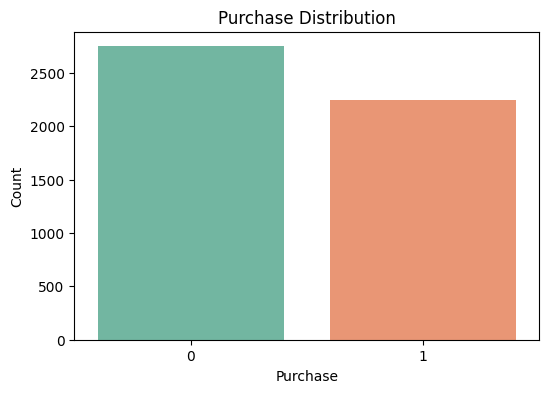

In [38]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Purchase",
    palette="Set2"
)

plt.title("Purchase Distribution")
plt.xlabel("Purchase")
plt.ylabel("Count")

plt.savefig("../reports/visualizations/purchase_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
purchase_rate = df["Purchase"].value_counts(normalize=True) * 100

print(purchase_rate)

Purchase
0    55.0
1    45.0
Name: proportion, dtype: float64


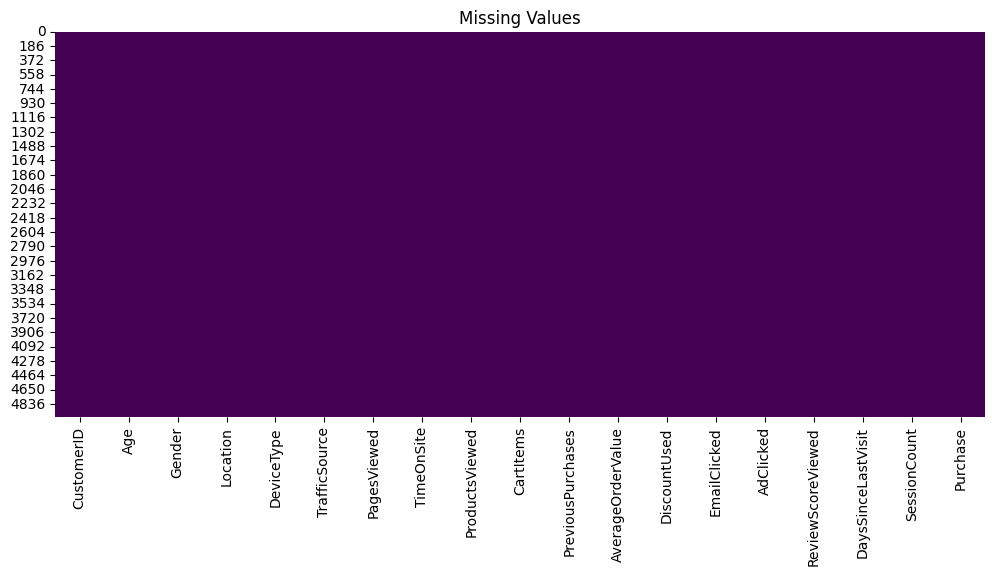

In [40]:
plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values")

plt.savefig("../reports/visualizations/missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

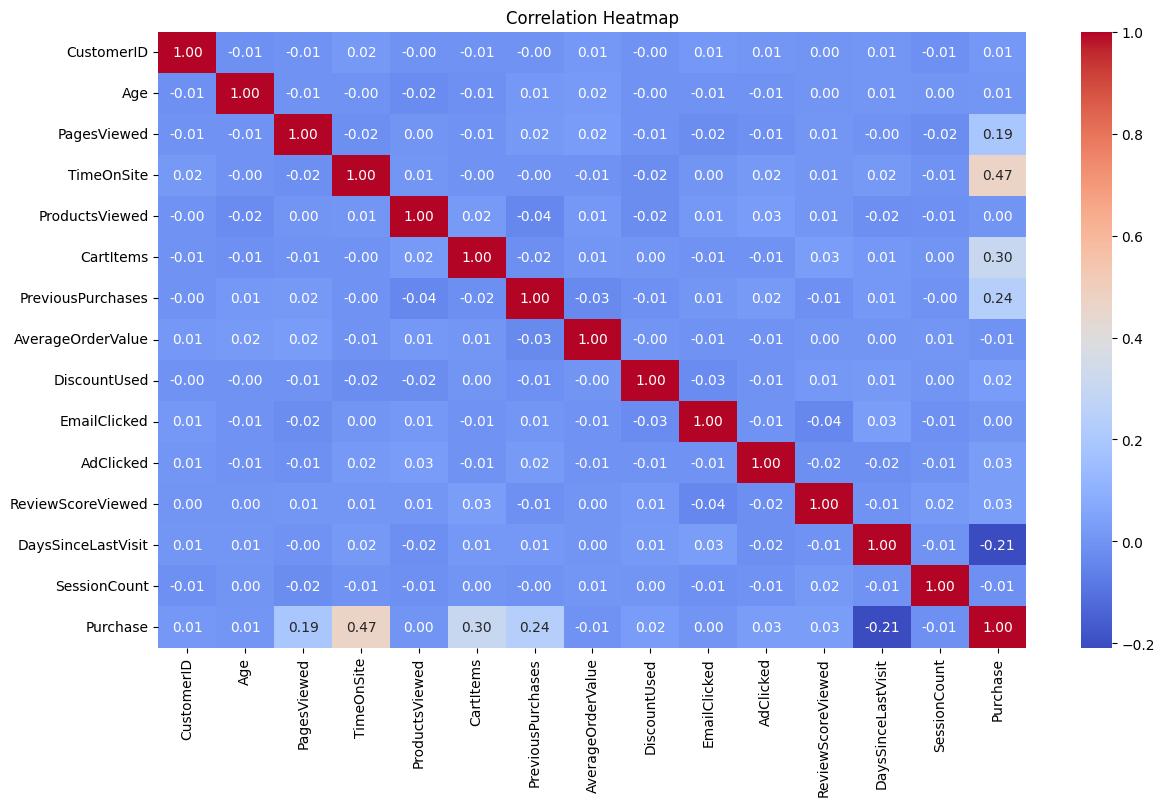

In [41]:
plt.figure(figsize=(14,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("../reports/visualizations/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

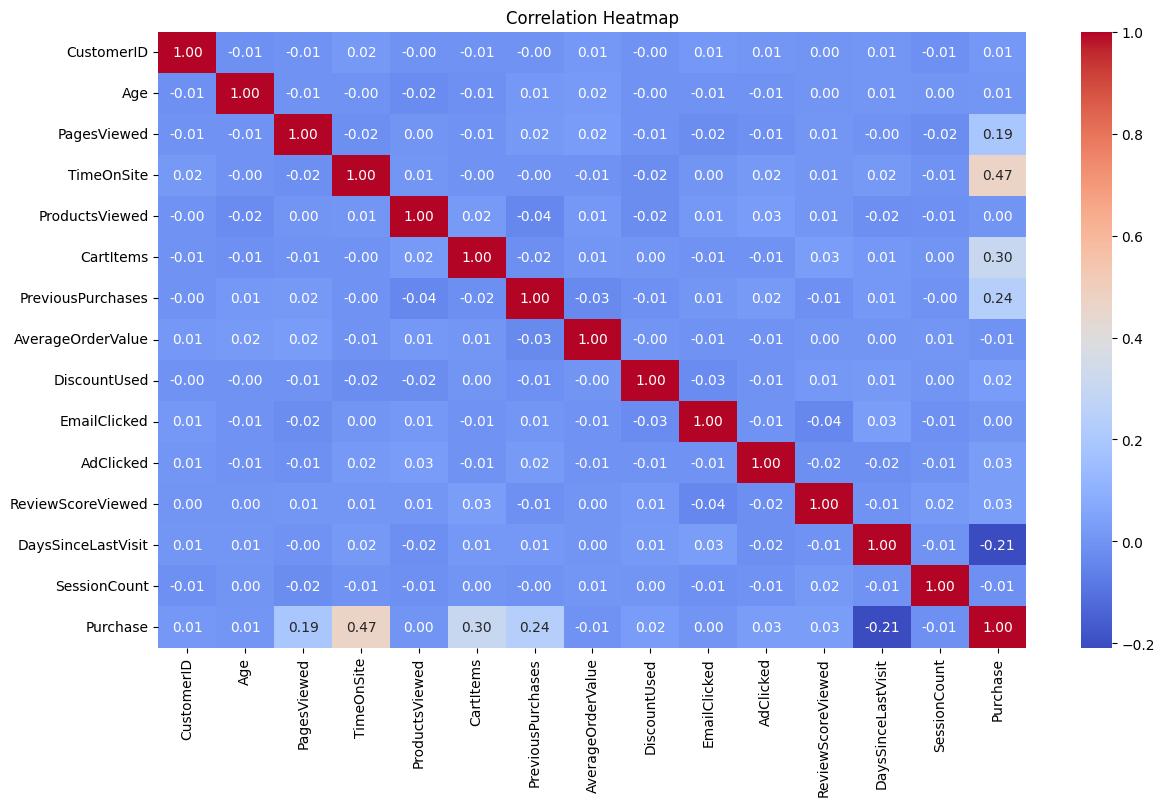

In [42]:
plt.figure(figsize=(14,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("../reports/visualizations/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
X = df.drop("Purchase", axis=1)
y = df["Purchase"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (5000, 18)
Target Shape: (5000,)


In [44]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['CustomerID', 'Age', 'PagesViewed', 'TimeOnSite', 'ProductsViewed', 'CartItems', 'PreviousPurchases', 'AverageOrderValue', 'DiscountUsed', 'EmailClicked', 'AdClicked', 'ReviewScoreViewed', 'DaysSinceLastVisit', 'SessionCount']

Categorical Columns:
['Gender', 'Location', 'DeviceType', 'TrafficSource']


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (4000, 18)
Testing Shape: (1000, 18)


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numerical_columns),
        ("categorical", categorical_pipeline, categorical_columns)
    ]
)

print("Preprocessing Pipeline Created Successfully!")

Preprocessing Pipeline Created Successfully!


In [47]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression Trained Successfully!")

Logistic Regression Trained Successfully!


In [48]:
predictions = logistic_pipeline.predict(X_test)
probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall   :", recall_score(y_test, predictions))
print("F1 Score :", f1_score(y_test, predictions))
print("ROC AUC  :", roc_auc_score(y_test, probabilities))

print("\nClassification Report\n")
print(classification_report(y_test, predictions))

Accuracy : 0.821
Precision: 0.8017817371937639
Recall   : 0.8
F1 Score : 0.8008898776418243
ROC AUC  : 0.9011838383838384

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       550
           1       0.80      0.80      0.80       450

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



In [49]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree Trained Successfully!")

Decision Tree Trained Successfully!


In [50]:
dt_predictions = decision_tree_pipeline.predict(X_test)
dt_probabilities = decision_tree_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, dt_predictions))
print("Precision:", precision_score(y_test, dt_predictions))
print("Recall   :", recall_score(y_test, dt_predictions))
print("F1 Score :", f1_score(y_test, dt_predictions))
print("ROC AUC  :", roc_auc_score(y_test, dt_probabilities))

Accuracy : 0.728
Precision: 0.6977777777777778
Recall   : 0.6977777777777778
F1 Score : 0.6977777777777778
ROC AUC  : 0.7252525252525253


In [51]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest Trained Successfully!")

Random Forest Trained Successfully!


In [52]:
rf_predictions = random_forest_pipeline.predict(X_test)
rf_probabilities = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall   :", recall_score(y_test, rf_predictions))
print("F1 Score :", f1_score(y_test, rf_predictions))
print("ROC AUC  :", roc_auc_score(y_test, rf_probabilities))

Accuracy : 0.813
Precision: 0.8199513381995134
Recall   : 0.7488888888888889
F1 Score : 0.7828106852497096
ROC AUC  : 0.8866222222222223


In [53]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    "Precision": [
        precision_score(y_test, predictions),
        precision_score(y_test, dt_predictions),
        precision_score(y_test, rf_predictions)
    ],
    "Recall": [
        recall_score(y_test, predictions),
        recall_score(y_test, dt_predictions),
        recall_score(y_test, rf_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, predictions),
        f1_score(y_test, dt_predictions),
        f1_score(y_test, rf_predictions)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, probabilities),
        roc_auc_score(y_test, dt_probabilities),
        roc_auc_score(y_test, rf_probabilities)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.821,0.801782,0.800000,0.800890,0.901184
1,Decision Tree,0.728,0.697778,0.697778,0.697778,0.725253
2,Random Forest,0.813,0.819951,0.748889,0.782811,0.886622


In [54]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__C': 0.01, 'classifier__solver': 'lbfgs'}

Best ROC-AUC:
0.9086262626262626


In [55]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(X_test)
best_probabilities = best_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, best_predictions))
print("Precision:", precision_score(y_test, best_predictions))
print("Recall   :", recall_score(y_test, best_predictions))
print("F1 Score :", f1_score(y_test, best_predictions))
print("ROC AUC  :", roc_auc_score(y_test, best_probabilities))

Accuracy : 0.822
Precision: 0.8076923076923077
Recall   : 0.7933333333333333
F1 Score : 0.8004484304932735
ROC AUC  : 0.9017494949494951


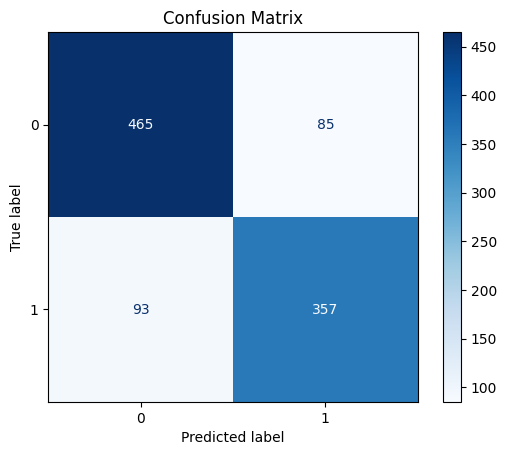

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig("../reports/visualizations/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

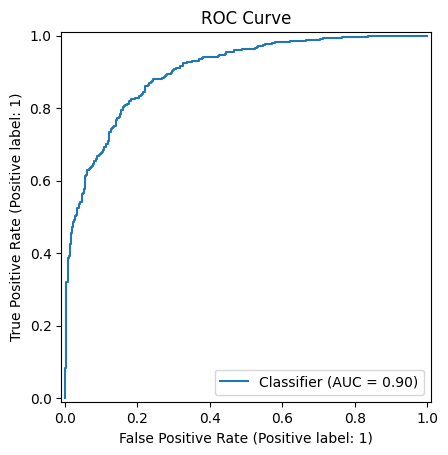

In [57]:
RocCurveDisplay.from_predictions(
    y_test,
    best_probabilities
)

plt.title("ROC Curve")

plt.savefig("../reports/visualizations/purchase_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
import os
import joblib

model_path = os.path.join(
    "..",
    "models",
    "purchase_prediction_model.pkl"
)

joblib.dump(best_model, model_path)

print(f"Model saved successfully to:\n{model_path}")

Model saved successfully to:
..\models\purchase_prediction_model.pkl


In [59]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Total Features:", len(feature_names))

Total Features: 28


In [60]:
coefficients = best_model.named_steps[
    "classifier"
].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["AbsoluteCoefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="AbsoluteCoefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,AbsoluteCoefficient
3,numeric__TimeOnSite,1.261524,1.261524
5,numeric__CartItems,0.821355,0.821355
6,numeric__PreviousPurchases,0.669754,0.669754
12,numeric__DaysSinceLastVisit,-0.603794,0.603794
2,numeric__PagesViewed,0.530918,0.530918
8,numeric__DiscountUsed,0.131340,0.131340
11,numeric__ReviewScoreViewed,0.078034,0.078034
10,numeric__AdClicked,0.075204,0.075204
26,categorical__TrafficSource_Search,0.053274,0.053274
24,categorical__TrafficSource_Direct,-0.046805,0.046805


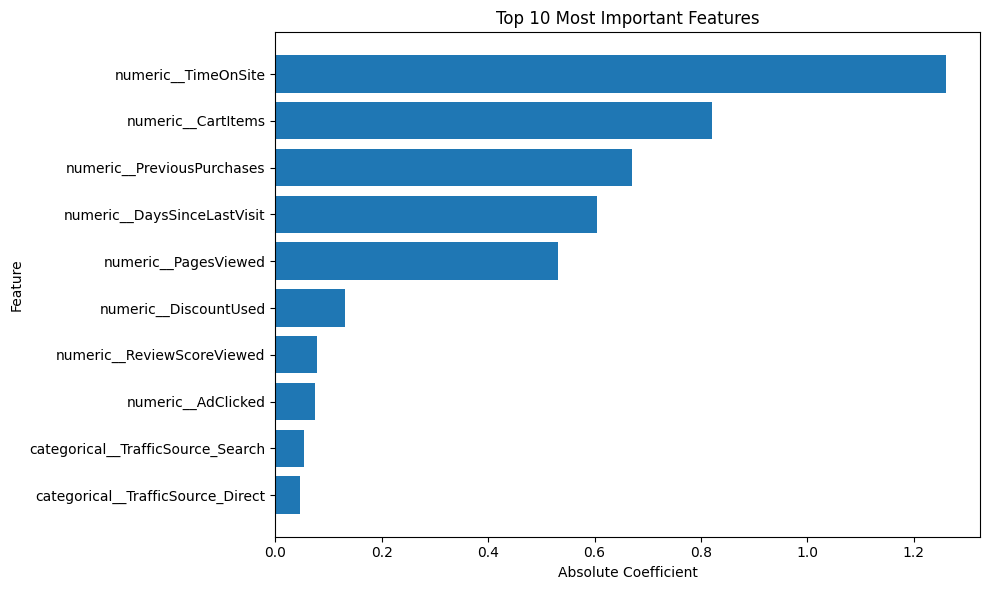

In [61]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["AbsoluteCoefficient"]
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../reports/visualizations/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [62]:
feature_importance.to_csv(
    "../reports/feature_importance_report.csv",
    index=False
)

print("Feature importance report saved successfully!")

Feature importance report saved successfully!


In [63]:
results = X_test.copy()

results["ActualPurchase"] = y_test.values

results["PurchaseProbability"] = best_probabilities

results["PurchaseLikelihood"] = pd.cut(
    results["PurchaseProbability"],
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=[
        "Low",
        "Medium",
        "High"
    ],
    include_lowest=True
)

results.head()

,CustomerID,Age,Gender,Location,DeviceType,TrafficSource,PagesViewed,TimeOnSite,ProductsViewed,CartItems,PreviousPurchases,AverageOrderValue,DiscountUsed,EmailClicked,AdClicked,ReviewScoreViewed,DaysSinceLastVisit,SessionCount,ActualPurchase,PurchaseProbability,PurchaseLikelihood
932,100933,49,Female,East,Mobile,Advertisement,22,808,18,1,0,38.35,1,0,1,4.9,5,13,0,0.481054,Medium
3105,103106,27,Male,East,Tablet,Advertisement,28,498,6,0,16,435.96,1,1,0,2.2,18,16,1,0.361500,Medium
3790,103791,56,Male,West,Mobile,Direct,20,328,11,5,10,221.07,0,0,1,3.1,55,2,0,0.119121,Low
4556,104557,67,Male,West,Desktop,Direct,21,827,8,6,9,32.08,1,1,0,4.0,56,12,1,0.573716,Medium
4726,104727,40,Female,South,Mobile,Search,3,1074,8,4,2,367.20,1,1,1,1.2,55,10,1,0.249176,Low


In [64]:
results.to_csv(
    "../reports/customer_purchase_predictions.csv",
    index=False
)

print("Customer predictions saved successfully!")

Customer predictions saved successfully!


In [65]:
comparison.loc[len(comparison)] = [
    "Optimized Logistic Regression",
    accuracy_score(y_test, best_predictions),
    precision_score(y_test, best_predictions),
    recall_score(y_test, best_predictions),
    f1_score(y_test, best_predictions),
    roc_auc_score(y_test, best_probabilities)
]

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.821,0.801782,0.800000,0.800890,0.901184
1,Decision Tree,0.728,0.697778,0.697778,0.697778,0.725253
2,Random Forest,0.813,0.819951,0.748889,0.782811,0.886622
3,Optimized Logistic Regression,0.822,0.807692,0.793333,0.800448,0.901749


# Conclusion

This project successfully developed an optimized machine learning model to predict whether an e-commerce customer is likely to complete a purchase.

Three classification algorithms were evaluated:
- Logistic Regression
- Decision Tree
- Random Forest

Logistic Regression achieved the best overall ROC-AUC score after hyperparameter optimization and was selected as the final model.

Feature importance analysis identified the variables that most strongly influenced purchase likelihood, enabling meaningful business insights.

The trained model can help businesses:
- Identify high-potential customers.
- Improve marketing efficiency.
- Personalize recommendations and promotions.
- Increase conversion rates.
- Support data-driven decision-making.